# Özellik Mühendisliği ve Dermason-Sira Analizi

Bu notebook'un amacı Dry Bean veri setinde en çok karışan Dermason-Sira sınıf çiftini incelemektir.

Özellik mühendisliği denemelerinin bu iki sınıfı ayırmada anlamlı katkı sağlayıp sağlamadığı test edilir.

Amaç skor artırmak değil, yeni özelliklerin gerçekten yeni bilgi taşıyıp taşımadığını analiz etmektir.


## 1. Kütüphaneler

Analiz için gerekli temel veri işleme, görselleştirme ve modelleme kütüphaneleri yüklenir.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


## 2. Dosya Yolları

Veri dosyaları proje köküne göre relative path ile tanımlanır. Öncelik temiz CSV dosyasındadır; CSV yoksa orijinal Excel dosyası okunur.


In [2]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
dataset_path = DATA_DIR / "dry_bean_clean.csv"
excel_path = DATA_DIR / "Dry_Bean_Dataset.xlsx"

print("CSV path:", dataset_path)
print("Excel fallback path:", excel_path)


CSV path: ..\data\dry_bean_clean.csv
Excel fallback path: ..\data\Dry_Bean_Dataset.xlsx


## 3. Veri Yükleme ve Kısa Kontrol

Bu bölümde veri temizliği yapılmaz. Analiz notebook'u olduğu için yalnızca mevcut durum kontrol edilir.


In [3]:
if dataset_path.exists():
    df = pd.read_csv(dataset_path)
elif excel_path.exists():
    df = pd.read_excel(excel_path)
else:
    raise FileNotFoundError("dry_bean_clean.csv veya Dry_Bean_Dataset.xlsx bulunamadı.")

display(df.head())
print("Veri boyutu:", df.shape)
display(df["Class"].value_counts().rename_axis("Class").reset_index(name="Count"))
display(df.isna().sum().rename("Missing_Count").to_frame())
print("Duplicate satır sayısı:", df.duplicated().sum())


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


Veri boyutu: (13543, 17)


,Class,Count
0,DERMASON,3546
1,SIRA,2636
2,SEKER,2027
3,HOROZ,1860
4,CALI,1630
5,BARBUNYA,1322
6,BOMBAY,522


,Missing_Count
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


Duplicate satır sayısı: 0


## 4. Dermason ve Sira Alt Veri Setini Oluşturma

Analiz yalnızca Dermason ve Sira sınıfları üzerinde yapılır. Hedef değişken binary hale getirilir: Dermason = 0, Sira = 1.


In [4]:
class_normalized = df["Class"].astype(str).str.upper().str.strip()
df_ds = df[class_normalized.isin(["DERMASON", "SIRA"])].copy()
df_ds["Class"] = df_ds["Class"].astype(str).str.upper().str.strip().map({"DERMASON": "Dermason", "SIRA": "Sira"})

display(df_ds["Class"].value_counts().rename_axis("Class").reset_index(name="Count"))
X_ds = df_ds.drop(columns=["Class"])
y_ds = df_ds["Class"].map({"Dermason": 0, "Sira": 1})
print("X_ds boyutu:", X_ds.shape)
print("y_ds sınıf kodları:", sorted(y_ds.unique()))


,Class,Count
0,Dermason,3546
1,Sira,2636


X_ds boyutu: (6182, 16)
y_ds sınıf kodları: [np.int64(0), np.int64(1)]


## 5. Temel Özellik Listesi

Orijinal 16 morfolojik özellik aşağıda listelenmiştir. Bu değişkenler zaten görüntü işleme sonucunda çıkarılmış morfolojik bilgileri temsil eder.

Özellikle `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `AspectRation`, `Eccentricity`, `ConvexArea`, `EquivDiameter`, `Extent`, `Solidity`, `roundness`, `Compactness` ve `ShapeFactor1-4` özellikleri kullanılır.


In [5]:
base_features = [
    "Area", "Perimeter", "MajorAxisLength", "MinorAxisLength",
    "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter",
    "Extent", "Solidity", "roundness", "Compactness",
    "ShapeFactor1", "ShapeFactor2", "ShapeFactor3", "ShapeFactor4",
]
missing_base_features = [feature for feature in base_features if feature not in X_ds.columns]
if missing_base_features:
    raise ValueError(f"Eksik temel özellikler: {missing_base_features}")
base_features


['Area',
 'Perimeter',
 'MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'ConvexArea',
 'EquivDiameter',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4']

## 6. Dermason-Sira İçin Temel Model Performansı

Yeni feature eklemeden önce orijinal 16 özellik ile baseline performans alınır.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ds[base_features], y_ds, test_size=0.2, random_state=42, stratify=y_ds
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVC RBF": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
}
baseline_results, baseline_reports, baseline_confusions = [], {}, {}
for model_name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    baseline_results.append({"Model": model_name, "Accuracy": accuracy_score(y_test, y_pred), "Weighted_F1": f1_score(y_test, y_pred, average="weighted")})
    baseline_reports[model_name] = classification_report(y_test, y_pred, target_names=["Dermason", "Sira"], output_dict=True)
    baseline_confusions[model_name] = confusion_matrix(y_test, y_pred)

display(pd.DataFrame(baseline_results))
for model_name in baseline_models:
    print(f"\n{model_name} classification report")
    display(pd.DataFrame(baseline_reports[model_name]).T)
    display(pd.DataFrame(baseline_confusions[model_name], index=["Gerçek Dermason", "Gerçek Sira"], columns=["Tahmin Dermason", "Tahmin Sira"]))


,Model,Accuracy,Weighted_F1
0,Logistic Regression,0.911884,0.912066
1,SVC RBF,0.923201,0.923112



Logistic Regression classification report


,precision,recall,f1-score,support
Dermason,0.934877,0.909859,0.922198,710.000000
Sira,0.882784,0.914611,0.898416,527.000000
accuracy,0.911884,0.911884,0.911884,0.911884
macro avg,0.908830,0.912235,0.910307,1237.000000
weighted avg,0.912684,0.911884,0.912066,1237.000000


,Tahmin Dermason,Tahmin Sira
Gerçek Dermason,646,64
Gerçek Sira,45,482



SVC RBF classification report


,precision,recall,f1-score,support
Dermason,0.927677,0.939437,0.933520,710.000000
Sira,0.916988,0.901328,0.909091,527.000000
accuracy,0.923201,0.923201,0.923201,0.923201
macro avg,0.922333,0.920382,0.921305,1237.000000
weighted avg,0.923124,0.923201,0.923112,1237.000000


,Tahmin Dermason,Tahmin Sira
Gerçek Dermason,667,43
Gerçek Sira,52,475


## 7. Random Forest Feature Importance

Bu analiz, Dermason-Sira ayrımında modelin en çok hangi morfolojik özelliklerden yararlandığını göstermektedir.


,Feature,Importance
1,Perimeter,0.211711
6,ConvexArea,0.183405
7,EquivDiameter,0.120412
0,Area,0.117679
2,MajorAxisLength,0.086123
3,MinorAxisLength,0.056692
12,ShapeFactor1,0.045778
10,roundness,0.033358
13,ShapeFactor2,0.031483
15,ShapeFactor4,0.024533


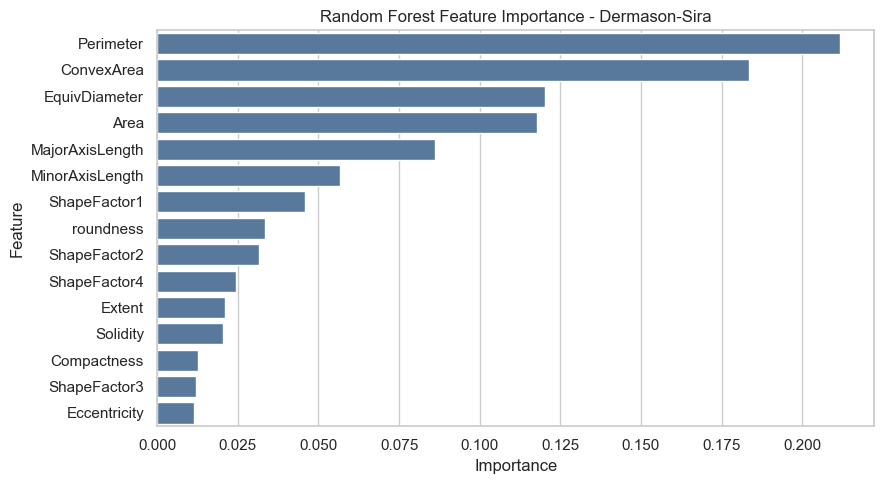

In [7]:
rf_base = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_base.fit(X_train, y_train)
rf_importance = pd.DataFrame({"Feature": base_features, "Importance": rf_base.feature_importances_}).sort_values("Importance", ascending=False)
display(rf_importance.head(15))
plt.figure(figsize=(9, 5))
sns.barplot(data=rf_importance.head(15), x="Importance", y="Feature", color="#4C78A8")
plt.title("Random Forest Feature Importance - Dermason-Sira")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. Permutation Importance

Random forest impurity importance yanlı olabilir. Bu nedenle alternatif bir önem ölçümü olarak permutation importance hesaplanır.


In [8]:
perm_result = permutation_importance(rf_base, X_test, y_test, n_repeats=10, random_state=42, scoring="f1_weighted")
permutation_table = pd.DataFrame({
    "Feature": base_features,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_Std": perm_result.importances_std,
}).sort_values("Permutation_Importance_Mean", ascending=False)
display(permutation_table.head(15))


,Feature,Permutation_Importance_Mean,Permutation_Importance_Std
10,roundness,0.017173,0.003730
1,Perimeter,0.008076,0.003221
15,ShapeFactor4,0.007815,0.003177
9,Solidity,0.003776,0.001775
6,ConvexArea,0.003416,0.002832
12,ShapeFactor1,0.002445,0.001410
2,MajorAxisLength,0.002139,0.000525
7,EquivDiameter,0.002127,0.001375
8,Extent,0.001893,0.002389
13,ShapeFactor2,0.001734,0.001758


Random Forest importance ve permutation importance birlikte değerlendirildiğinde, öne çıkan özelliklerin çoğu büyüklük ve şekil bilgisini taşıyan morfolojik değişkenlerdir. Permutation importance, modele gerçekten katkı veren özellikleri test seti üzerinde ölçtüğü için impurity importance sonucunu dengeleyen bir kontrol sağlar.


## 9. Korelasyon Analizi

Mevcut özelliklerin birbirini tekrar edip etmediğini görmek için Dermason-Sira alt veri setindeki sayısal özelliklerin korelasyon matrisi incelenir.


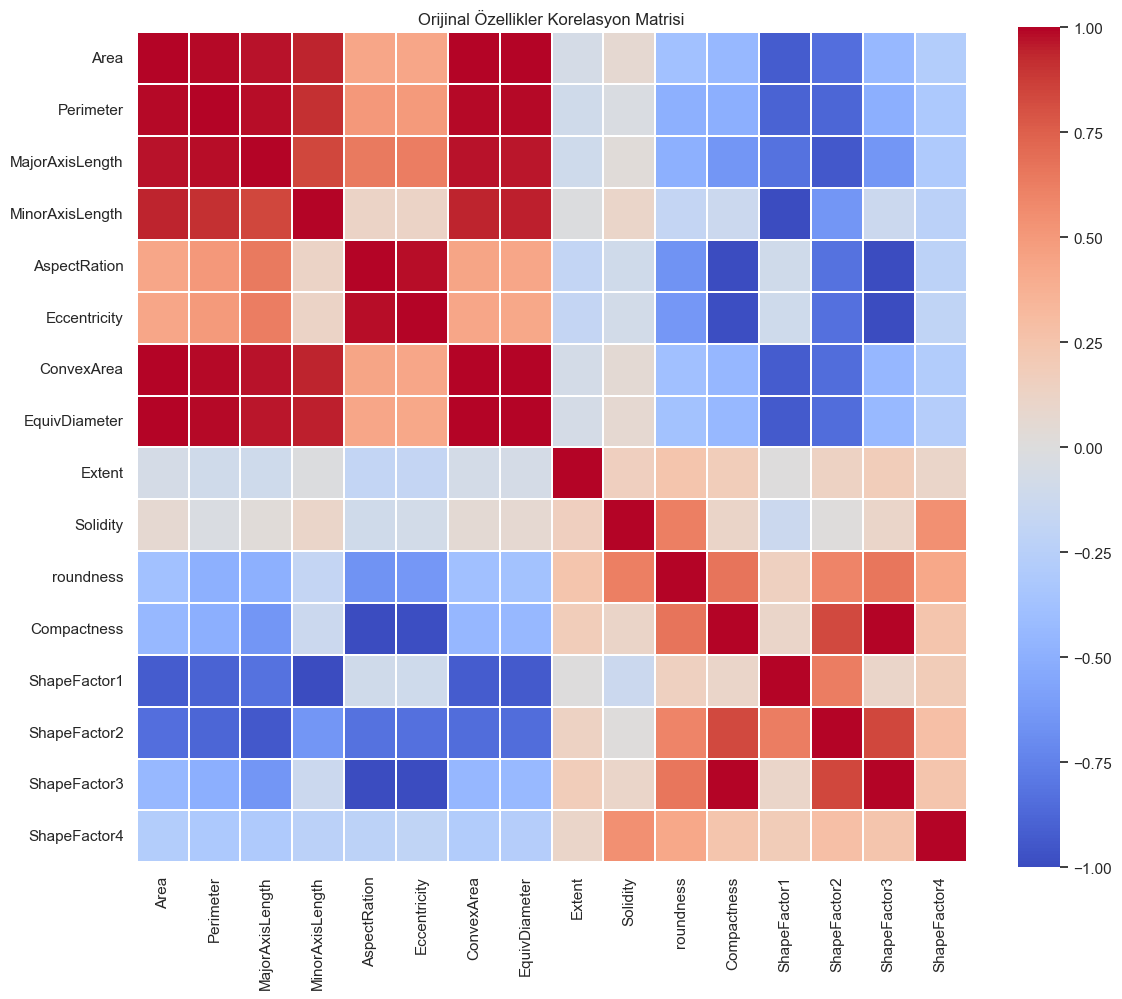

,Feature_1,Feature_2,Correlation,Abs_Correlation
3,Area,ConvexArea,0.999899,0.999899
24,Compactness,ShapeFactor3,0.999681,0.999681
4,Area,EquivDiameter,0.998469,0.998469
21,ConvexArea,EquivDiameter,0.998299,0.998299
17,AspectRation,Compactness,-0.996765,0.996765
20,Eccentricity,ShapeFactor3,-0.994815,0.994815
18,AspectRation,ShapeFactor3,-0.994618,0.994618
15,MinorAxisLength,ShapeFactor1,-0.993619,0.993619
19,Eccentricity,Compactness,-0.992109,0.992109
8,Perimeter,ConvexArea,0.990505,0.990505


In [9]:
corr_matrix = df_ds[base_features].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.3)
plt.title("Orijinal Özellikler Korelasyon Matrisi")
plt.tight_layout()
plt.show()
high_corr_pairs = []
for i, feature_a in enumerate(base_features):
    for feature_b in base_features[i + 1:]:
        corr_value = corr_matrix.loc[feature_a, feature_b]
        if abs(corr_value) > 0.90:
            high_corr_pairs.append({"Feature_1": feature_a, "Feature_2": feature_b, "Correlation": corr_value, "Abs_Correlation": abs(corr_value)})
high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("Abs_Correlation", ascending=False)
display(high_corr_df)


Yüksek korelasyonlu özelliklerin fazla olması, yeni türetilen özelliklerin neden sınırlı katkı verebileceğini açıklayabilir.


## 10. Engineered Feature Fonksiyonu

Yeni özellikler tek bir fonksiyon içinde üretilir. Bölme işlemlerinde sıfıra bölme riskini azaltmak için küçük bir epsilon değeri kullanılır.


In [10]:
def create_engineered_features(df):
    eps = 1e-9
    engineered_df = df.copy()
    engineered_df["Major_Minor_Ratio"] = engineered_df["MajorAxisLength"] / (engineered_df["MinorAxisLength"] + eps)
    engineered_df["Area_Perimeter_Ratio"] = engineered_df["Area"] / (engineered_df["Perimeter"] + eps)
    engineered_df["Perimeter_Area_Ratio"] = engineered_df["Perimeter"] / (engineered_df["Area"] + eps)
    engineered_df["ConvexArea_Area_Ratio"] = engineered_df["ConvexArea"] / (engineered_df["Area"] + eps)
    engineered_df["Area_ConvexArea_Ratio"] = engineered_df["Area"] / (engineered_df["ConvexArea"] + eps)
    engineered_df["Compact_Round"] = engineered_df["Compactness"] * engineered_df["roundness"]
    engineered_df["Compact_Solidity"] = engineered_df["Compactness"] * engineered_df["Solidity"]
    engineered_df["Round_Solidity"] = engineered_df["roundness"] * engineered_df["Solidity"]
    engineered_df["Eccentricity_Aspect"] = engineered_df["Eccentricity"] * engineered_df["AspectRation"]
    engineered_df["Major_Minor_Product"] = engineered_df["MajorAxisLength"] * engineered_df["MinorAxisLength"]
    engineered_df["Area_Sqrt"] = np.sqrt(engineered_df["Area"])
    engineered_df["Perimeter_Sqrt"] = np.sqrt(engineered_df["Perimeter"])
    engineered_df["Area_Log"] = np.log1p(engineered_df["Area"])
    engineered_df["Perimeter_Log"] = np.log1p(engineered_df["Perimeter"])
    engineered_df["MajorAxis_Log"] = np.log1p(engineered_df["MajorAxisLength"])
    engineered_df["MinorAxis_Log"] = np.log1p(engineered_df["MinorAxisLength"])
    engineered_df["SF1_SF2_Ratio"] = engineered_df["ShapeFactor1"] / (engineered_df["ShapeFactor2"] + eps)
    engineered_df["SF3_SF4_Ratio"] = engineered_df["ShapeFactor3"] / (engineered_df["ShapeFactor4"] + eps)
    engineered_df["SF1_Compact"] = engineered_df["ShapeFactor1"] * engineered_df["Compactness"]
    engineered_df["SF2_Round"] = engineered_df["ShapeFactor2"] * engineered_df["roundness"]
    engineered_df["SF3_Eccentricity"] = engineered_df["ShapeFactor3"] * engineered_df["Eccentricity"]
    return engineered_df


## 11. Engineered Feature Seti Oluşturma

Dermason-Sira alt veri seti üzerinde engineered feature'lar oluşturulur ve özellik sayısındaki değişim kontrol edilir.


In [11]:
df_engineered = create_engineered_features(df_ds)
engineered_features = [feature for feature in df_engineered.columns if feature not in df_ds.columns]
all_features = base_features + engineered_features
X_eng = df_engineered[all_features]
y_eng = df_engineered["Class"].map({"Dermason": 0, "Sira": 1})
print("Orijinal özellik sayısı:", len(base_features))
print("Engineered sonrası özellik sayısı:", len(all_features))
print("Eklenen yeni feature sayısı:", len(engineered_features))
engineered_features


Orijinal özellik sayısı: 16
Engineered sonrası özellik sayısı: 37
Eklenen yeni feature sayısı: 21


['Major_Minor_Ratio',
 'Area_Perimeter_Ratio',
 'Perimeter_Area_Ratio',
 'ConvexArea_Area_Ratio',
 'Area_ConvexArea_Ratio',
 'Compact_Round',
 'Compact_Solidity',
 'Round_Solidity',
 'Eccentricity_Aspect',
 'Major_Minor_Product',
 'Area_Sqrt',
 'Perimeter_Sqrt',
 'Area_Log',
 'Perimeter_Log',
 'MajorAxis_Log',
 'MinorAxis_Log',
 'SF1_SF2_Ratio',
 'SF3_SF4_Ratio',
 'SF1_Compact',
 'SF2_Round',
 'SF3_Eccentricity']

## 12. Engineered Feature Korelasyon Kontrolü

Yeni üretilen özelliklerin mevcut özelliklerin kopyası olup olmadığı, orijinal feature'larla maksimum mutlak korelasyonları üzerinden incelenir.


In [12]:
engineered_corr = df_engineered[all_features].corr(numeric_only=True)
engineered_corr_rows = []
for engineered_feature in engineered_features:
    correlations = engineered_corr.loc[engineered_feature, base_features].abs().sort_values(ascending=False)
    engineered_corr_rows.append({
        "Engineered_Feature": engineered_feature,
        "Most_Correlated_Original_Feature": correlations.index[0],
        "Abs_Correlation": correlations.iloc[0],
    })
engineered_corr_table = pd.DataFrame(engineered_corr_rows).sort_values("Abs_Correlation", ascending=False)
display(engineered_corr_table)


,Engineered_Feature,Most_Correlated_Original_Feature,Abs_Correlation
0,Major_Minor_Ratio,AspectRation,1.000000
10,Area_Sqrt,EquivDiameter,1.000000
4,Area_ConvexArea_Ratio,Solidity,1.000000
3,ConvexArea_Area_Ratio,Solidity,0.999935
9,Major_Minor_Product,ConvexArea,0.999933
11,Perimeter_Sqrt,Perimeter,0.999543
17,SF3_SF4_Ratio,ShapeFactor3,0.999436
8,Eccentricity_Aspect,AspectRation,0.999208
15,MinorAxis_Log,MinorAxisLength,0.998588
12,Area_Log,EquivDiameter,0.998428


Yeni feature'ların çoğunun mevcut özelliklerle çok yüksek korelasyon göstermesi, bu feature'ların modele yeni bilgi taşımadığını gösterebilir.


## 13. Baseline vs Engineered Karşılaştırması

Aynı train-test split kullanılarak orijinal 16 feature seti ile orijinal + engineered feature seti karşılaştırılır.


In [13]:
base_indices = X_ds.index
train_idx, test_idx = train_test_split(base_indices, test_size=0.2, random_state=42, stratify=y_ds)
feature_sets = {"Original_16": X_ds.loc[:, base_features], "Original_plus_Engineered": X_eng.loc[:, all_features]}
comparison_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "SVC RBF": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
}
comparison_results = []
for feature_set_name, X_current in feature_sets.items():
    X_train_current = X_current.loc[train_idx]
    X_test_current = X_current.loc[test_idx]
    y_train_current = y_ds.loc[train_idx]
    y_test_current = y_ds.loc[test_idx]
    scaler = StandardScaler()
    X_train_current_scaled = scaler.fit_transform(X_train_current)
    X_test_current_scaled = scaler.transform(X_test_current)
    for model_name, model in comparison_models.items():
        model.fit(X_train_current_scaled, y_train_current)
        y_pred_current = model.predict(X_test_current_scaled)
        comparison_results.append({
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "Accuracy": accuracy_score(y_test_current, y_pred_current),
            "Weighted_F1": f1_score(y_test_current, y_pred_current, average="weighted"),
        })
comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)
display(comparison_df.pivot(index="Model", columns="Feature_Set", values="Weighted_F1"))


,Model,Feature_Set,Accuracy,Weighted_F1
0,Logistic Regression,Original_16,0.911884,0.912066
1,SVC RBF,Original_16,0.923201,0.923112
2,Logistic Regression,Original_plus_Engineered,0.914309,0.914478
3,SVC RBF,Original_plus_Engineered,0.922393,0.922271


Feature_Set,Original_16,Original_plus_Engineered
Model,,
Logistic Regression,0.912066,0.914478
SVC RBF,0.923112,0.922271


## 14. Cross Validation ile Daha Adil Karşılaştırma

Tek split yanıltıcı olabilir. Bu nedenle 5-fold StratifiedKFold ile weighted F1 skorları karşılaştırılır.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "SVC RBF": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
}
for feature_set_name, X_current in feature_sets.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_current)
    for model_name, model in cv_models.items():
        scores = cross_val_score(model, X_scaled, y_ds, cv=cv, scoring="f1_weighted")
        cv_results.append({
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "CV_Weighted_F1_Mean": scores.mean(),
            "CV_Weighted_F1_Std": scores.std(),
        })
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)


,Model,Feature_Set,CV_Weighted_F1_Mean,CV_Weighted_F1_Std
0,Logistic Regression,Original_16,0.922499,0.009576
1,SVC RBF,Original_16,0.927529,0.007733
2,Logistic Regression,Original_plus_Engineered,0.922824,0.008397
3,SVC RBF,Original_plus_Engineered,0.927054,0.007479


## 15. Engineered Feature Importance

Yeni feature'ların Random Forest importance sıralamasında üst sıralara çıkıp çıkmadığı incelenir.


,Feature,Importance,Is_Engineered
27,Perimeter_Sqrt,0.124927,True
1,Perimeter,0.115785,False
29,Perimeter_Log,0.094151,True
6,ConvexArea,0.087276,False
25,Major_Minor_Product,0.073686,True
0,Area,0.067452,False
26,Area_Sqrt,0.050327,True
28,Area_Log,0.050276,True
7,EquivDiameter,0.041451,False
34,SF1_Compact,0.030887,True


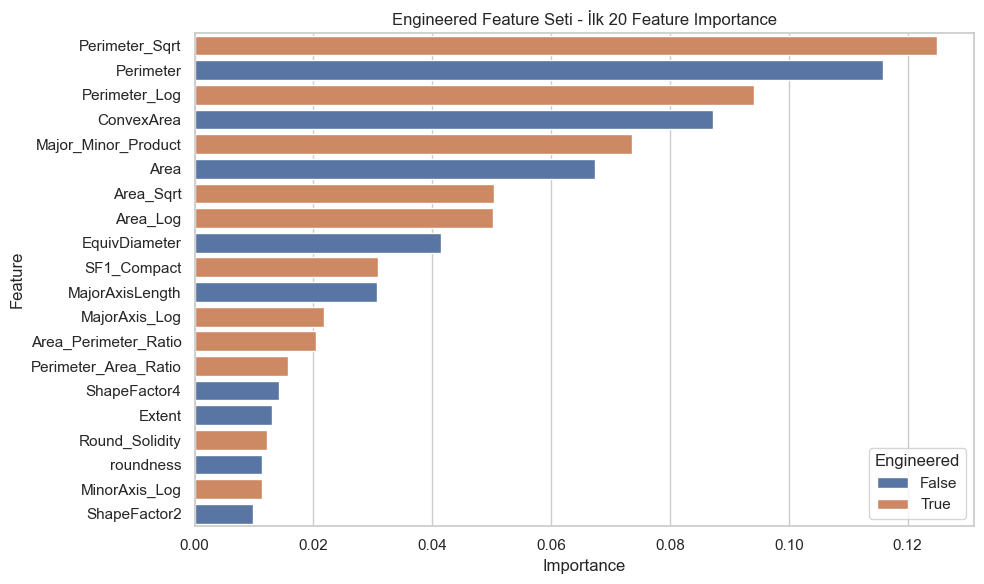

In [15]:
X_train_eng = X_eng.loc[train_idx, all_features]
y_train_eng = y_ds.loc[train_idx]
rf_engineered = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_engineered.fit(X_train_eng, y_train_eng)
engineered_importance = pd.DataFrame({"Feature": all_features, "Importance": rf_engineered.feature_importances_})
engineered_importance["Is_Engineered"] = engineered_importance["Feature"].isin(engineered_features)
engineered_importance = engineered_importance.sort_values("Importance", ascending=False)
display(engineered_importance.head(20))
plt.figure(figsize=(10, 6))
sns.barplot(data=engineered_importance.head(20), x="Importance", y="Feature", hue="Is_Engineered", dodge=False)
plt.title("Engineered Feature Seti - İlk 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend(title="Engineered")
plt.tight_layout()
plt.show()


Yeni üretilen özelliklerin üst sıralarda sınırlı yer alması veya mevcut özelliklerle benzer bilgi taşıması, performans artışının sınırlı kalmasını açıklamaktadır.


## 16. Son Teknik Değerlendirme

- Dermason-Sira çifti veri setinde en çok karışan sınıflardan biri olarak incelenmiştir.
- Orijinal 16 morfolojik özellik üzerinde baseline modeller kurulmuştur.
- Random Forest ve permutation importance analizleri, ayrımı taşıyan ana özelliklerin sınırlı sayıda olduğunu göstermiştir.
- Üretilen yeni geometrik/oran/log/kombinasyon özellikleri denenmiştir.
- Ancak bu özelliklerin çoğu mevcut morfolojik özelliklerle yüksek korelasyon göstermiştir.
- Bu nedenle engineered feature seti, Dermason-Sira ayrımında anlamlı ve kalıcı bir performans artışı sağlamamıştır.
- Bu sonuç, mevcut veri setindeki 16 morfolojik özelliğin zaten güçlü geometrik bilgi taşıdığını göstermektedir.


## 17. Repeated Stratified K-Fold ile Stabilite Kontrolü

Bu bölümde Dermason–SIRA ayrımı için yalnızca orijinal 16 özellik kullanılarak modellerin farklı veri bölünmelerinde ne kadar stabil çalıştığı test edilmiştir. Tek bir train-test split yerine RepeatedStratifiedKFold kullanılmıştır. Böylece sonuçların rastgele bölünmeye bağlı olup olmadığı kontrol edilmiştir.

In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score

def pair_macro_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

scoring = {
    "macro_f1": make_scorer(pair_macro_f1_score),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
}

stability_models = {
    "Logistic + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "Logistic + RobustScaler": Pipeline([
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "SVC RBF + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ]),
    "SVC RBF + RobustScaler": Pipeline([
        ("scaler", RobustScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ]),
    "SVC RBF + PowerTransformer": Pipeline([
        ("scaler", PowerTransformer(method="yeo-johnson")),
        ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ]),
    "SVC RBF + QuantileTransformer": Pipeline([
        ("scaler", QuantileTransformer(output_distribution="normal", random_state=42)),
        ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ]),
}

stability_results = []

for model_name, pipeline in stability_models.items():
    scores = cross_validate(
        pipeline,
        X_ds[base_features],
        y_ds,
        cv=repeated_cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    stability_results.append({
        "Model": model_name,
        "Macro_F1_Mean": scores["test_macro_f1"].mean(),
        "Macro_F1_Std": scores["test_macro_f1"].std(),
        "Balanced_Accuracy_Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced_Accuracy_Std": scores["test_balanced_accuracy"].std(),
    })

stability_results_df = pd.DataFrame(stability_results).sort_values(
    by="Macro_F1_Mean",
    ascending=False
)

display(stability_results_df)

,Model,Macro_F1_Mean,Macro_F1_Std,Balanced_Accuracy_Mean,Balanced_Accuracy_Std
5,SVC RBF + QuantileTransformer,0.925699,0.004967,0.923760,0.004780
3,SVC RBF + RobustScaler,0.925487,0.004951,0.923993,0.004815
4,SVC RBF + PowerTransformer,0.924768,0.004437,0.923011,0.004398
2,SVC RBF + StandardScaler,0.924698,0.004978,0.922934,0.005059
1,Logistic + RobustScaler,0.920101,0.006385,0.919909,0.006221
0,Logistic + StandardScaler,0.919958,0.006471,0.919709,0.006300


### Repeated Stratified K-Fold sonucu

RepeatedStratifiedKFold sonuçlarına göre Dermason–SIRA ayrımında en yüksek ortalama Macro F1 değeri `SVC RBF + QuantileTransformer` kombinasyonunda elde edilmiştir. Ancak SVC-RBF modelleri arasındaki farklar oldukça küçüktür ve standart sapma değerleri bu farklardan büyüktür. Bu nedenle QuantileTransformer sonucu tek başına kesin bir üstünlük olarak değil, SVC-RBF model ailesinin genel olarak daha stabil çalıştığını gösteren bir bulgu olarak değerlendirilmiştir.

Logistic Regression sonuçlarının SVC-RBF modellerinden daha düşük kalması, Dermason–SIRA ayrımında doğrusal olmayan bir karar sınırının daha uygun olabileceğini göstermektedir. Buna rağmen en iyi sonuçlar yaklaşık 0.925 Macro F1 seviyesinde kalmış, bu da mevcut 16 morfolojik özellik ile iki sınıf arasındaki geçiş/overlap bölgesinin tamamen çözülemediğini desteklemektedir.

## 18. Temel Model Aileleri ile Stabilite Kontrolü

Bu bölümde Dermason–SIRA ayrımı için farklı temel model aileleri aynı tekrarlı çapraz doğrulama protokolüyle karşılaştırılmıştır. Amaç yeni özellik üretmek değil, mevcut 16 morfolojik özellikle hangi klasik model ailesinin daha stabil çalıştığını görmektir.

In [17]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
import numpy as np

# Repeated CV ayarı
model_family_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

# Skorlar
model_family_scoring = {
    "macro_f1": make_scorer(f1_score, average="macro"),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
}

# Not:
# X_ds ve y_ds daha önce Dermason-SIRA binary dataset için oluşturulmuş olmalı.
# base_features = orijinal 16 feature listesi olmalı.

model_family_pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=42
        ))
    ]),

    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            C=1.0,
            max_iter=10000,
            random_state=42
        ))
    ]),

    "SVC RBF + StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=42
        ))
    ]),

    "SVC RBF + QuantileTransformer": Pipeline([
        ("scaler", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight=None
        ))
    ]),

    "ExtraTrees": Pipeline([
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight=None
        ))
    ]),

    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis())
    ]),

    "LDA shrinkage": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        ))
    ]),
}

model_family_results = []

for model_name, pipeline in model_family_pipelines.items():
    print(f"Çalışıyor: {model_name}")
    
    scores = cross_validate(
        pipeline,
        X_ds[base_features],
        y_ds,
        cv=model_family_cv,
        scoring=model_family_scoring,
        n_jobs=-1,
        error_score="raise"
    )
    
    model_family_results.append({
        "Model": model_name,
        "Macro_F1_Mean": scores["test_macro_f1"].mean(),
        "Macro_F1_Std": scores["test_macro_f1"].std(),
        "Balanced_Accuracy_Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced_Accuracy_Std": scores["test_balanced_accuracy"].std(),
        "Precision_Macro_Mean": scores["test_precision_macro"].mean(),
        "Precision_Macro_Std": scores["test_precision_macro"].std(),
        "Recall_Macro_Mean": scores["test_recall_macro"].mean(),
        "Recall_Macro_Std": scores["test_recall_macro"].std(),
    })

model_family_results_df = pd.DataFrame(model_family_results).sort_values(
    by="Macro_F1_Mean",
    ascending=False
).reset_index(drop=True)

display(model_family_results_df)

Çalışıyor: Logistic Regression
Çalışıyor: LinearSVC
Çalışıyor: SVC RBF + StandardScaler
Çalışıyor: SVC RBF + QuantileTransformer
Çalışıyor: Random Forest
Çalışıyor: ExtraTrees
Çalışıyor: LDA
Çalışıyor: LDA shrinkage


,Model,Macro_F1_Mean,Macro_F1_Std,Balanced_Accuracy_Mean,Balanced_Accuracy_Std,Precision_Macro_Mean,Precision_Macro_Std,Recall_Macro_Mean,Recall_Macro_Std
0,SVC RBF + QuantileTransformer,0.925699,0.004967,0.923760,0.004780,0.928175,0.005407,0.923760,0.004780
1,SVC RBF + StandardScaler,0.924698,0.004978,0.922934,0.005059,0.926929,0.005082,0.922934,0.005059
2,Random Forest,0.922238,0.004501,0.920616,0.004379,0.924261,0.004877,0.920616,0.004379
3,LinearSVC,0.920088,0.006460,0.919489,0.006328,0.920807,0.006695,0.919489,0.006328
4,Logistic Regression,0.919958,0.006471,0.919709,0.006300,0.920306,0.006746,0.919709,0.006300
5,ExtraTrees,0.918398,0.006738,0.916986,0.006537,0.920122,0.007133,0.916986,0.006537
6,LDA shrinkage,0.917197,0.006087,0.914784,0.006362,0.920443,0.005756,0.914784,0.006362
7,LDA,0.914362,0.004839,0.915762,0.004648,0.913279,0.004994,0.915762,0.004648


## 19. En İyi Model İçin Threshold Optimizasyonu

Bu bölümde önceki analizlerde en iyi performansı veren `SVC RBF + QuantileTransformer` modeli için karar eşiği optimizasyonu denenmiştir. Amaç, varsayılan karar sınırı yerine validation fold üzerinde seçilen farklı eşiklerin Dermason–SIRA ayrımında Macro F1 değerini artırıp artırmadığını test etmektir. Threshold seçimi test verisi üzerinde yapılmamış, her fold içinde yalnızca eğitim/validation ayrımı kullanılmıştır.

In [18]:
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)
import numpy as np
import pandas as pd

def create_best_svc_pipeline():
    return Pipeline([
        ("scaler", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=False,
            random_state=42
        ))
    ])

# Daha makul grid: önce 61 yeterli
threshold_grid = np.linspace(-1.5, 1.5, 61)

outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

X_pair = X_ds[base_features].copy()
y_pair = y_ds.copy()

threshold_results = []

print("Binary class labels:", np.unique(y_pair))

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X_pair, y_pair), start=1):
    print(f"Outer fold {fold_id}/25 çalışıyor...")

    X_train_outer = X_pair.iloc[train_idx]
    X_test_outer = X_pair.iloc[test_idx]

    y_train_outer = y_pair.iloc[train_idx] if hasattr(y_pair, "iloc") else y_pair[train_idx]
    y_test_outer = y_pair.iloc[test_idx] if hasattr(y_pair, "iloc") else y_pair[test_idx]

    # Baseline threshold = 0
    baseline_model = create_best_svc_pipeline()
    baseline_model.fit(X_train_outer, y_train_outer)

    baseline_scores = baseline_model.decision_function(X_test_outer)
    baseline_pred = (baseline_scores >= 0).astype(int)

    baseline_macro_f1 = f1_score(y_test_outer, baseline_pred, average="macro")
    baseline_bal_acc = balanced_accuracy_score(y_test_outer, baseline_pred)
    baseline_precision = precision_score(y_test_outer, baseline_pred, average="macro", zero_division=0)
    baseline_recall = recall_score(y_test_outer, baseline_pred, average="macro", zero_division=0)

    # Threshold skorlarını burada biriktiriyoruz
    threshold_to_scores = {thr: [] for thr in threshold_grid}

    # ÖNEMLİ: Her inner fold için model sadece 1 kere eğitiliyor
    for inner_train_idx, inner_valid_idx in inner_cv.split(X_train_outer, y_train_outer):
        X_train_inner = X_train_outer.iloc[inner_train_idx]
        X_valid_inner = X_train_outer.iloc[inner_valid_idx]

        if hasattr(y_train_outer, "iloc"):
            y_train_inner = y_train_outer.iloc[inner_train_idx]
            y_valid_inner = y_train_outer.iloc[inner_valid_idx]
        else:
            y_train_inner = y_train_outer[inner_train_idx]
            y_valid_inner = y_train_outer[inner_valid_idx]

        inner_model = create_best_svc_pipeline()
        inner_model.fit(X_train_inner, y_train_inner)

        valid_scores = inner_model.decision_function(X_valid_inner)

        # Aynı valid_scores üzerinden tüm threshold'lar deneniyor
        for thr in threshold_grid:
            valid_pred = (valid_scores >= thr).astype(int)
            threshold_to_scores[thr].append(
                f1_score(y_valid_inner, valid_pred, average="macro")
            )

    threshold_scores = []

    for thr, score_list in threshold_to_scores.items():
        threshold_scores.append({
            "threshold": thr,
            "inner_macro_f1_mean": np.mean(score_list),
            "inner_macro_f1_std": np.std(score_list)
        })

    threshold_scores_df = pd.DataFrame(threshold_scores)

    best_row = threshold_scores_df.sort_values(
        by="inner_macro_f1_mean",
        ascending=False
    ).iloc[0]

    best_threshold = best_row["threshold"]
    best_inner_macro_f1 = best_row["inner_macro_f1_mean"]

    # Outer test değerlendirme
    tuned_model = create_best_svc_pipeline()
    tuned_model.fit(X_train_outer, y_train_outer)

    test_scores = tuned_model.decision_function(X_test_outer)
    tuned_pred = (test_scores >= best_threshold).astype(int)

    tuned_macro_f1 = f1_score(y_test_outer, tuned_pred, average="macro")
    tuned_bal_acc = balanced_accuracy_score(y_test_outer, tuned_pred)
    tuned_precision = precision_score(y_test_outer, tuned_pred, average="macro", zero_division=0)
    tuned_recall = recall_score(y_test_outer, tuned_pred, average="macro", zero_division=0)

    threshold_results.append({
        "Fold": fold_id,
        "Selected_Threshold": best_threshold,
        "Inner_CV_Macro_F1": best_inner_macro_f1,
        "Baseline_Macro_F1": baseline_macro_f1,
        "Tuned_Macro_F1": tuned_macro_f1,
        "Delta_Macro_F1": tuned_macro_f1 - baseline_macro_f1,
        "Baseline_Balanced_Accuracy": baseline_bal_acc,
        "Tuned_Balanced_Accuracy": tuned_bal_acc,
        "Delta_Balanced_Accuracy": tuned_bal_acc - baseline_bal_acc,
        "Baseline_Precision_Macro": baseline_precision,
        "Tuned_Precision_Macro": tuned_precision,
        "Baseline_Recall_Macro": baseline_recall,
        "Tuned_Recall_Macro": tuned_recall,
        "Baseline_CM": confusion_matrix(y_test_outer, baseline_pred).tolist(),
        "Tuned_CM": confusion_matrix(y_test_outer, tuned_pred).tolist()
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df.head())

threshold_summary = pd.DataFrame([{
    "Method": "SVC RBF + QuantileTransformer + threshold tuning",
    "Baseline_Macro_F1_Mean": threshold_results_df["Baseline_Macro_F1"].mean(),
    "Tuned_Macro_F1_Mean": threshold_results_df["Tuned_Macro_F1"].mean(),
    "Mean_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].mean(),
    "Median_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].median(),
    "Std_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].std(),
    "Positive_Fold_Count": int((threshold_results_df["Delta_Macro_F1"] > 0).sum()),
    "Total_Fold_Count": len(threshold_results_df),
    "Positive_Ratio": (threshold_results_df["Delta_Macro_F1"] > 0).mean(),
    "Mean_Selected_Threshold": threshold_results_df["Selected_Threshold"].mean(),
    "Std_Selected_Threshold": threshold_results_df["Selected_Threshold"].std(),
    "Baseline_Balanced_Accuracy_Mean": threshold_results_df["Baseline_Balanced_Accuracy"].mean(),
    "Tuned_Balanced_Accuracy_Mean": threshold_results_df["Tuned_Balanced_Accuracy"].mean(),
    "Mean_Delta_Balanced_Accuracy": threshold_results_df["Delta_Balanced_Accuracy"].mean(),
}])

display(threshold_summary)

Binary class labels: [0 1]
Outer fold 1/25 çalışıyor...
Outer fold 2/25 çalışıyor...
Outer fold 3/25 çalışıyor...
Outer fold 4/25 çalışıyor...
Outer fold 5/25 çalışıyor...
Outer fold 6/25 çalışıyor...
Outer fold 7/25 çalışıyor...
Outer fold 8/25 çalışıyor...
Outer fold 9/25 çalışıyor...
Outer fold 10/25 çalışıyor...
Outer fold 11/25 çalışıyor...
Outer fold 12/25 çalışıyor...
Outer fold 13/25 çalışıyor...
Outer fold 14/25 çalışıyor...
Outer fold 15/25 çalışıyor...
Outer fold 16/25 çalışıyor...
Outer fold 17/25 çalışıyor...
Outer fold 18/25 çalışıyor...
Outer fold 19/25 çalışıyor...
Outer fold 20/25 çalışıyor...
Outer fold 21/25 çalışıyor...
Outer fold 22/25 çalışıyor...
Outer fold 23/25 çalışıyor...
Outer fold 24/25 çalışıyor...
Outer fold 25/25 çalışıyor...


,Fold,Selected_Threshold,Inner_CV_Macro_F1,Baseline_Macro_F1,Tuned_Macro_F1,Delta_Macro_F1,Baseline_Balanced_Accuracy,Tuned_Balanced_Accuracy,Delta_Balanced_Accuracy,Baseline_Precision_Macro,Tuned_Precision_Macro,Baseline_Recall_Macro,Tuned_Recall_Macro,Baseline_CM,Tuned_CM
0,1,0.00,0.927152,0.927895,0.927895,0.000000,0.926558,0.926558,0.000000,0.929452,0.929452,0.926558,0.926558,"[[672, 37], [50, 478]]","[[672, 37], [50, 478]]"
1,2,-0.05,0.923902,0.933538,0.933609,0.000072,0.931435,0.931924,0.000489,0.936168,0.935631,0.931435,0.931924,"[[680, 30], [50, 477]]","[[678, 32], [48, 479]]"
2,3,0.00,0.928030,0.908803,0.908803,0.000000,0.907813,0.907813,0.000000,0.909919,0.909919,0.907813,0.907813,"[[659, 50], [60, 467]]","[[659, 50], [60, 467]]"
3,4,0.15,0.924974,0.928352,0.921318,-0.007035,0.925469,0.916905,-0.008564,0.932272,0.928303,0.925469,0.916905,"[[680, 29], [57, 470]]","[[684, 25], [69, 458]]"
4,5,0.10,0.925803,0.926077,0.922499,-0.003579,0.924327,0.919558,-0.004769,0.928205,0.926544,0.924327,0.919558,"[[673, 36], [53, 474]]","[[677, 32], [61, 466]]"


,Method,Baseline_Macro_F1_Mean,Tuned_Macro_F1_Mean,Mean_Delta_Macro_F1,Median_Delta_Macro_F1,Std_Delta_Macro_F1,Positive_Fold_Count,Total_Fold_Count,Positive_Ratio,Mean_Selected_Threshold,Std_Selected_Threshold,Baseline_Balanced_Accuracy_Mean,Tuned_Balanced_Accuracy_Mean,Mean_Delta_Balanced_Accuracy
0,SVC RBF + QuantileTransformer + threshold tuning,0.925699,0.925507,-0.000192,0.0,0.002947,11,25,0.44,-0.02,0.112731,0.92376,0.923795,0.000035


In [19]:
threshold_summary = pd.DataFrame([{
    "Method": "SVC RBF + QuantileTransformer + threshold tuning",
    "Baseline_Macro_F1_Mean": threshold_results_df["Baseline_Macro_F1"].mean(),
    "Tuned_Macro_F1_Mean": threshold_results_df["Tuned_Macro_F1"].mean(),
    "Mean_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].mean(),
    "Median_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].median(),
    "Std_Delta_Macro_F1": threshold_results_df["Delta_Macro_F1"].std(),
    "Positive_Fold_Count": int((threshold_results_df["Delta_Macro_F1"] > 0).sum()),
    "Total_Fold_Count": len(threshold_results_df),
    "Positive_Ratio": (threshold_results_df["Delta_Macro_F1"] > 0).mean(),
    "Mean_Selected_Threshold": threshold_results_df["Selected_Threshold"].mean(),
    "Std_Selected_Threshold": threshold_results_df["Selected_Threshold"].std(),
    "Baseline_Balanced_Accuracy_Mean": threshold_results_df["Baseline_Balanced_Accuracy"].mean(),
    "Tuned_Balanced_Accuracy_Mean": threshold_results_df["Tuned_Balanced_Accuracy"].mean(),
    "Mean_Delta_Balanced_Accuracy": threshold_results_df["Delta_Balanced_Accuracy"].mean(),
}])

display(threshold_summary)

,Method,Baseline_Macro_F1_Mean,Tuned_Macro_F1_Mean,Mean_Delta_Macro_F1,Median_Delta_Macro_F1,Std_Delta_Macro_F1,Positive_Fold_Count,Total_Fold_Count,Positive_Ratio,Mean_Selected_Threshold,Std_Selected_Threshold,Baseline_Balanced_Accuracy_Mean,Tuned_Balanced_Accuracy_Mean,Mean_Delta_Balanced_Accuracy
0,SVC RBF + QuantileTransformer + threshold tuning,0.925699,0.925507,-0.000192,0.0,0.002947,11,25,0.44,-0.02,0.112731,0.92376,0.923795,0.000035


In [20]:
threshold_results_path = "../reports/results/dermason_sira_threshold_tuning_repeated_cv.csv"
threshold_summary_path = "../reports/results/dermason_sira_threshold_tuning_summary.csv"

threshold_results_df.to_csv(threshold_results_path, index=False, encoding="utf-8-sig")
threshold_summary.to_csv(threshold_summary_path, index=False, encoding="utf-8-sig")

print(f"Threshold detay sonuçları kaydedildi: {threshold_results_path}")
print(f"Threshold özet sonuçları kaydedildi: {threshold_summary_path}")

Threshold detay sonuçları kaydedildi: ../reports/results/dermason_sira_threshold_tuning_repeated_cv.csv
Threshold özet sonuçları kaydedildi: ../reports/results/dermason_sira_threshold_tuning_summary.csv


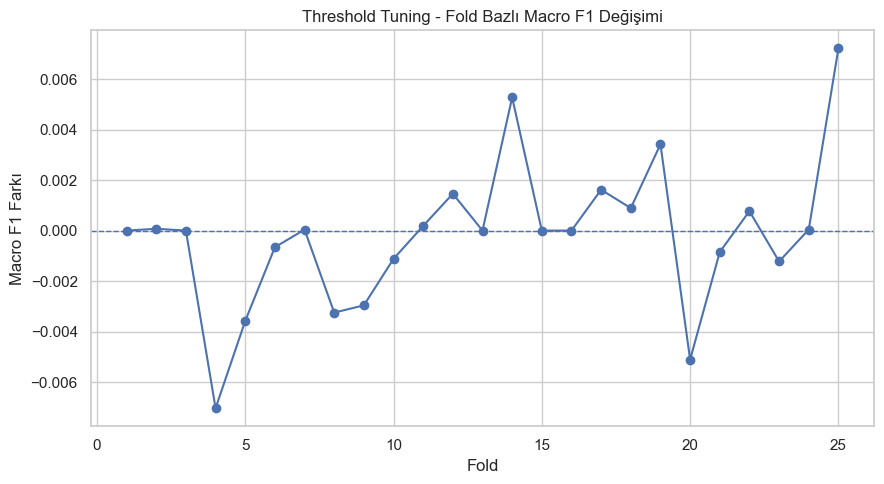

Grafik kaydedildi: ../reports/figures/dermason_sira_threshold_tuning_delta.png


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--", linewidth=1)
plt.plot(
    range(1, len(threshold_results_df) + 1),
    threshold_results_df["Delta_Macro_F1"],
    marker="o"
)
plt.xlabel("Fold")
plt.ylabel("Macro F1 Farkı")
plt.title("Threshold Tuning - Fold Bazlı Macro F1 Değişimi")
plt.tight_layout()

fig_path = "../reports/figures/dermason_sira_threshold_tuning_delta.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafik kaydedildi: {fig_path}")

SVC RBF + QuantileTransformer modeli için threshold tuning denenmiş, ancak tekrarlı çapraz doğrulama sonuçlarında güvenilir bir iyileştirme sağlamamıştır. Ortalama Macro F1 değeri çok küçük miktarda düşmüş, pozitif iyileşme yalnızca 11/25 fold’da görülmüştür. Seçilen threshold değerlerinin ortalama olarak varsayılan 0 eşiğine yakın olması, modelin mevcut karar sınırının zaten makul olduğunu göstermektedir.

## 20. Permutation Importance ile Özellik Etkisi Analizi

Bu bölümde en iyi stabil sonucu veren `SVC RBF + QuantileTransformer` modeli üzerinde permutation importance analizi yapılmıştır. Amaç, Dermason–SIRA ayrımında modelin hangi orijinal morfolojik özelliklerden daha fazla etkilendiğini görmektir. Permutation importance, bir özelliğin değerleri karıştırıldığında model performansının ne kadar düştüğünü ölçer. Performans düşüşü yüksekse, ilgili özelliğin model için daha önemli olduğu kabul edilir.

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def create_best_svc_pipeline():
    return Pipeline([
        ("scaler", QuantileTransformer(
            output_distribution="normal",
            random_state=42
        )),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=False,
            random_state=42
        ))
    ])

X_pair = X_ds[base_features].copy()
y_pair = y_ds.copy()

perm_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scorer = make_scorer(f1_score, average="macro")

importance_rows = []

for fold_id, (train_idx, valid_idx) in enumerate(perm_cv.split(X_pair, y_pair), start=1):
    X_train = X_pair.iloc[train_idx]
    X_valid = X_pair.iloc[valid_idx]

    y_train = y_pair.iloc[train_idx] if hasattr(y_pair, "iloc") else y_pair[train_idx]
    y_valid = y_pair.iloc[valid_idx] if hasattr(y_pair, "iloc") else y_pair[valid_idx]

    model = create_best_svc_pipeline()
    model.fit(X_train, y_train)

    perm_result = permutation_importance(
        model,
        X_valid,
        y_valid,
        scoring=scorer,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    for feature_name, mean_imp, std_imp in zip(
        base_features,
        perm_result.importances_mean,
        perm_result.importances_std
    ):
        importance_rows.append({
            "Fold": fold_id,
            "Feature": feature_name,
            "Importance_Mean": mean_imp,
            "Importance_Std": std_imp
        })

perm_importance_df = pd.DataFrame(importance_rows)

perm_summary_df = (
    perm_importance_df
    .groupby("Feature", as_index=False)
    .agg(
        Mean_Importance=("Importance_Mean", "mean"),
        Std_Importance=("Importance_Mean", "std"),
        Mean_Permutation_Std=("Importance_Std", "mean")
    )
    .sort_values(by="Mean_Importance", ascending=False)
    .reset_index(drop=True)
)

display(perm_summary_df)

,Feature,Mean_Importance,Std_Importance,Mean_Permutation_Std
0,roundness,0.052433,0.006239,0.005398
1,ShapeFactor1,0.018077,0.003968,0.004064
2,MinorAxisLength,0.017706,0.004058,0.003943
3,Perimeter,0.010507,0.005184,0.004204
4,Area,0.009116,0.004984,0.004542
5,EquivDiameter,0.009116,0.004984,0.004542
6,ConvexArea,0.008759,0.004965,0.004658
7,MajorAxisLength,0.006383,0.004982,0.003835
8,ShapeFactor4,0.005256,0.003804,0.002805
9,ShapeFactor2,0.004036,0.004883,0.002686


In [23]:
perm_output_path = "../reports/results/dermason_sira_permutation_importance.csv"

perm_summary_df.to_csv(
    perm_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Permutation importance sonuçları kaydedildi: {perm_output_path}")

Permutation importance sonuçları kaydedildi: ../reports/results/dermason_sira_permutation_importance.csv


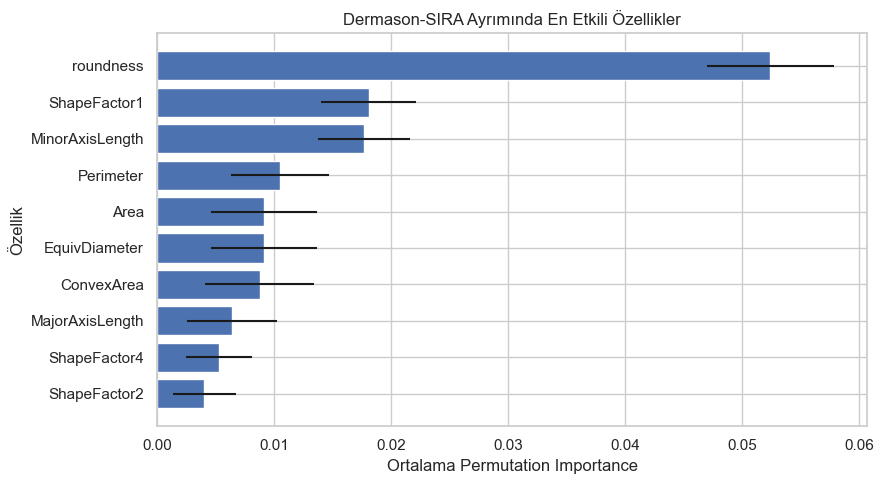

Grafik kaydedildi: ../reports/figures/dermason_sira_permutation_importance.png


In [24]:
top_n = 10
plot_df = perm_summary_df.head(top_n).copy()

plt.figure(figsize=(9, 5))
plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Importance"],
    xerr=plot_df["Mean_Permutation_Std"]
)
plt.xlabel("Ortalama Permutation Importance")
plt.ylabel("Özellik")
plt.title("Dermason-SIRA Ayrımında En Etkili Özellikler")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = "../reports/figures/dermason_sira_permutation_importance.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafik kaydedildi: {fig_path}")

Bu analiz, Dermason–SIRA ayrımında modelin en çok roundness ve bazı şekil/boyut özelliklerinden yararlandığını göstermektedir. Yeni özellik mühendisliği denemelerinin kararlı iyileştirme sağlamaması, mevcut özelliklerin zaten temel ayırıcı bilgileri büyük ölçüde içerdiği şeklinde yorumlanabilir.

## 21. Genel Değerlendirme ve Nihai Sonuç

Bu çalışmada Dry Bean veri setinde özellikle DERMASON ve SIRA sınıflarının ayrımı incelenmiştir. İlk aşamada yapay zekâ destekli özellik mühendisliği ile yeni türev özellikler üretilmiş, ancak bu özelliklerin büyük kısmının mevcut 16 morfolojik özelliğin taşıdığı bilgiyi tekrar ettiği veya modele güvenilir bir katkı sağlamadığı görülmüştür.

DERMASON ve SIRA sınıfları için yapılan hata analizi, yanlış sınıflandırmaların özellikle orta büyüklük/geçiş bandında yoğunlaştığını göstermiştir. Bu durum, iki sınıf arasında mevcut özellik uzayında gerçek bir örtüşme bölgesi bulunduğunu düşündürmektedir.

Sonraki aşamada hard-example weighting, threshold tuning, boundary cleaning ve ambiguous sample suppression gibi yöntemler denenmiştir. Bazı tekil veri bölünmelerinde küçük performans artışları görülse de çoklu random_state ve tekrarlı çapraz doğrulama testleri bu artışların kararlı olmadığını göstermiştir. Bu nedenle bu yöntemler güvenilir bir iyileştirme olarak kabul edilmemiştir.

Repeated Stratified K-Fold sonuçlarında en stabil model ailesinin RBF kernel SVM olduğu görülmüştür. Özellikle SVC RBF + QuantileTransformer kombinasyonu en yüksek ortalama Macro F1 değerini vermiştir. Ancak bu sonuç da DERMASON ve SIRA ayrımını tamamen çözmemiş, yaklaşık 0.925 Macro F1 seviyesinde kalmıştır.

Threshold optimizasyonu denendiğinde ortalama Macro F1 değerinde anlamlı bir artış görülmemiştir. Bu durum, SVC modelinin varsayılan karar sınırının zaten makul bir seviyede olduğunu ve eşik ayarlamanın bu problemde kararlı bir katkı sağlamadığını göstermektedir.

Permutation importance analizi sonucunda DERMASON-SIRA ayrımında en etkili özelliğin `roundness` olduğu görülmüştür. Bunun yanında `ShapeFactor1`, `MinorAxisLength`, `Perimeter`, `Area`, `EquivDiameter` ve `ConvexArea` özellikleri de modele katkı sağlamıştır. Bu bulgu, modelin ayrım yaparken özellikle yuvarlaklık, şekil karakteri ve boyut ilişkili özelliklerden yararlandığını göstermektedir.

Genel olarak, mevcut 16 morfolojik özellik ile DERMASON ve SIRA sınıfları arasında belirli bir başarı seviyesine ulaşılabilmektedir. Ancak yapılan özellik mühendisliği, eşik ayarı, sınır temizleme ve örnek ağırlıklandırma denemeleri bu ayrımı güvenilir ve tekrarlanabilir şekilde daha ileri taşıyamamıştır. Bu nedenle bu iki sınıf arasındaki hataların büyük ölçüde model eksikliğinden değil, mevcut özelliklerle tam ayrıştırılamayan doğal bir sınıf örtüşmesinden kaynaklandığı değerlendirilmiştir.

Daha yüksek ayrım başarısı için ham görüntü verileri, renk bilgisi, doku özellikleri, kontur tabanlı ek ölçümler veya daha detaylı morfolojik özellikler gerekebilir.

### Nihai Bulguların Özeti

| İncelenen Yöntem | Sonuç | Karar |
|---|---|---|
| Yapay zekâ destekli özellik mühendisliği | Küçük artışlar görüldü fakat güvenilir destek yok | Başarı sayılmadı |
| Dermason-SIRA özel feature engineering | Hold-out ve ablation desteklemedi | REDDEDİLDİ |
| Hard-example weighting + threshold tuning | Tek splitte iyileşti, çoklu seed’de kararsız | KARARSIZ |
| Boundary cleaning | Ortalama Macro F1 delta negatif | REDDEDİLDİ |
| Ambiguous sample suppression | Ortalama Macro F1 delta negatif | REDDEDİLDİ |
| SVC RBF + QuantileTransformer | En stabil temel model ailesi | En iyi güvenilir baseline |
| Threshold tuning | Ortalama Macro F1 artışı sağlamadı | REDDEDİLDİ |
| Permutation importance | En etkili özellik roundness | Açıklayıcı bulgu |